**步驟 1:環境準備與解壓縮資料集**

先將 archive.zip 上傳到 Google 雲端,然後執行以下程式碼。這段程式碼會自動解壓並透過隨機分配建立標準的機器學習資料夾結構。



In [2]:
import os
import zipfile
import random
import shutil
from google.colab import drive

# 1. 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# 2. 指定雲端硬碟中的壓縮檔路徑 (上傳到雲端硬碟最外層)
zip_path = '/content/drive/MyDrive/GastrointestinalBleeding.zip'
extract_path = 'raw_data'

# 印出檔案大小來確認檔案是健康的
print(f"正在檢查檔案大小... {os.path.getsize(zip_path) / (1024*1024):.2f} MB")

# 3. 執行解壓縮 (從雲端硬碟讀取)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("解壓縮完成！")

base_source_dir = os.path.join(extract_path, 'GastrointestinalBleeding')
classes = ['Lesion', 'Normal']
dataset_dir = 'dataset'
splits = ['train', 'val', 'test']

for s in splits:
    for c in classes:
        os.makedirs(os.path.join(dataset_dir, s, c), exist_ok=True)

random.seed(42)

for cls in classes:
    src_folder = os.path.join(base_source_dir, cls)
    all_imgs = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    random.shuffle(all_imgs)

    total = len(all_imgs)
    train_end = int(total * 0.7)
    val_end = train_end + int(total * 0.15)

    train_imgs = all_imgs[:train_end]
    val_imgs = all_imgs[train_end:val_end]
    test_imgs = all_imgs[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dataset_dir, 'train', cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dataset_dir, 'val', cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dataset_dir, 'test', cls, img))

print("資料集隨機分割與重組完成！結構已轉化為 dataset/ 內之 train, val, test。")

Mounted at /content/drive
正在檢查檔案大小... 595.98 MB
解壓縮完成！
資料集隨機分割與重組完成！結構已轉化為 dataset/ 內之 train, val, test。


**步驟 2：建置 PyTorch 資料擴增與 DataLoader**

在這裡引入多維度的資料擴增（旋轉、水平/垂直翻轉、色彩抖動），以虛擬擴大訓練集，強迫 ResNet18 學習更具泛化性的幾何與色彩特徵。同時，將批次大小 (Batch Size) 設為 16。因為樣本數只有 226 張，較小的 Batch Size 有助於提供更頻繁的梯度更新。


每個壓縮檔（Zip）打包時的內部結構都不太一樣。有時候壓縮檔解開後，圖片會藏在 archive/GastrointestinalBleeding/Lesion，或者資料夾名稱可能有空白（例如 Gastrointestinal Bleeding）。

執行下面這段資料救援與重建程式碼，直接掃描整個 raw_data 資料夾的每一個角落，只要看到 .png 或 .jpg，就看它的上一層資料夾叫什麼名字，然後自動抓出來分類。

In [3]:
import os
import random
import shutil

# 1. 先清空建錯的空資料夾，避免混淆
if os.path.exists('dataset'):
    shutil.rmtree('dataset')

dataset_dir = 'dataset'
classes = ['Lesion', 'Normal']
splits = ['train', 'val', 'test']

for s in splits:
    for c in classes:
        os.makedirs(os.path.join(dataset_dir, s, c), exist_ok=True)

# 2. 把所有圖片路徑找出來
lesion_imgs = []
normal_imgs = []

print("開始在 raw_data 資料夾中進行地毯式搜索...")
for root, dirs, files in os.walk('raw_data'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            full_path = os.path.join(root, file)
            # 透過路徑名稱判斷是 Lesion 還是 Normal
            if 'lesion' in full_path.lower():
                lesion_imgs.append(full_path)
            elif 'normal' in full_path.lower():
                normal_imgs.append(full_path)

print(f"結果：找到 {len(lesion_imgs)} 張 Lesion 圖片，{len(normal_imgs)} 張 Normal 圖片")

# 3. 如果成功找到，就開始精準分割與複製
if len(lesion_imgs) == 0 or len(normal_imgs) == 0:
    print("還是找不到！壓縮檔裡可能沒有圖片，或者副檔名很奇怪。")
else:
    random.seed(42)
    random.shuffle(lesion_imgs)
    random.shuffle(normal_imgs)

    def split_and_copy(img_list, cls_name):
        total = len(img_list)
        train_end = int(total * 0.7)
        val_end = train_end + int(total * 0.15)

        for i, img_path in enumerate(img_list):
            if i < train_end:
                dest = os.path.join(dataset_dir, 'train', cls_name, os.path.basename(img_path))
            elif i < val_end:
                dest = os.path.join(dataset_dir, 'val', cls_name, os.path.basename(img_path))
            else:
                dest = os.path.join(dataset_dir, 'test', cls_name, os.path.basename(img_path))
            shutil.copy(img_path, dest)

    split_and_copy(lesion_imgs, 'Lesion')
    split_and_copy(normal_imgs, 'Normal')
    print("完美修復！圖片已全數歸位！")

開始在 raw_data 資料夾中進行地毯式搜索...
結果：找到 113 張 Lesion 圖片，113 張 Normal 圖片
完美修復！圖片已全數歸位！


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 影像尺寸統一縮放為 ResNet18 的標準輸入 224x224
img_size = 224

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 載入資料集
train_dataset = datasets.ImageFolder(root='dataset/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='dataset/val', transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root='dataset/test', transform=val_test_transforms)

# 建立 DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"訓練集批次數: {len(train_loader)}, 驗證集批次數: {len(val_loader)}, 測試集批次數: {len(test_loader)}")
print(f"類別對應索引: {train_dataset.class_to_idx}")


訓練集批次數: 10, 驗證集批次數: 2, 測試集批次數: 3
類別對應索引: {'Lesion': 0, 'Normal': 1}


**步驟 3：定義 ResNet18 遷移學習模型**

載入 PyTorch 官方預訓練好的 ResNet18。ResNet18 使用殘差連接（Residual Connection）來改善深層網路訓練時的梯度問題，適合拿來做小型影像資料集的遷移學習。

因為本資料集只有 226 張圖片，若從零開始訓練模型容易過擬合，因此這裡使用 ImageNet 預訓練權重，並把最後的全連接層 `fc` 改成二元分類輸出：`Lesion` 與 `Normal`。


In [5]:
import torch.nn as nn
from torchvision import models

# 載入 PyTorch 官方 ResNet18 預訓練權重
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 替換 ResNet18 末端的全連接層 fc。原本輸出是 1000 類，改成二元分類 (2)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# 將模型部署至 GPU / CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"模型成功部署至: {device}")
print("目前模型：ResNet18")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


模型成功部署至: cuda
目前模型：ResNet18


**步驟 4：編寫核心訓練、驗證與最佳權重儲存控制迴圈**

在小資料集訓練中，必須每輪（Epoch）監控驗證集的 Loss。一旦發現 Validation Loss 創新低，立即儲存模型。防止模型在訓練後期發生過擬合。

In [6]:
import torch.optim as optim
import torch

criterion = nn.CrossEntropyLoss()
# 使用 Adam 優化器，初始學習率設低 (1e-4) 以避免破壞預訓練特徵
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 30
best_val_loss = float('inf')

print("開始訓練模型...")
for epoch in range(num_epochs):
    # --- 訓練階段 ---
    model.train()
    train_loss = 0.0
    train_corrects = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)
        total_train_samples += inputs.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_corrects.double() / total_train_samples

    # --- 驗證階段 ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val_samples = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            total_val_samples += inputs.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_corrects.double() / total_val_samples

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    # 儲存最佳模型
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_resnet18_model.pth')
        print("[系統提示] 驗證集表現提升，最佳模型權重已存檔。")

開始訓練模型...
Epoch 01/30 | Train Loss: 0.6807 Acc: 0.5886 | Val Loss: 0.5443 Acc: 0.6875
[系統提示] 驗證集表現提升，最佳模型權重已存檔。
Epoch 02/30 | Train Loss: 0.3633 Acc: 0.8734 | Val Loss: 0.5154 Acc: 0.7500
[系統提示] 驗證集表現提升，最佳模型權重已存檔。
Epoch 03/30 | Train Loss: 0.3212 Acc: 0.8797 | Val Loss: 0.4831 Acc: 0.8438
[系統提示] 驗證集表現提升，最佳模型權重已存檔。
Epoch 04/30 | Train Loss: 0.3027 Acc: 0.8861 | Val Loss: 0.4639 Acc: 0.8438
[系統提示] 驗證集表現提升，最佳模型權重已存檔。
Epoch 05/30 | Train Loss: 0.2314 Acc: 0.9177 | Val Loss: 0.5085 Acc: 0.8125
Epoch 06/30 | Train Loss: 0.2003 Acc: 0.9367 | Val Loss: 0.4657 Acc: 0.8438
Epoch 07/30 | Train Loss: 0.1139 Acc: 0.9684 | Val Loss: 0.6243 Acc: 0.8438
Epoch 08/30 | Train Loss: 0.1016 Acc: 0.9684 | Val Loss: 0.6055 Acc: 0.8438
Epoch 09/30 | Train Loss: 0.1030 Acc: 0.9620 | Val Loss: 0.4226 Acc: 0.8438
[系統提示] 驗證集表現提升，最佳模型權重已存檔。
Epoch 10/30 | Train Loss: 0.2440 Acc: 0.9114 | Val Loss: 0.3987 Acc: 0.8750
[系統提示] 驗證集表現提升，最佳模型權重已存檔。
Epoch 11/30 | Train Loss: 0.0858 Acc: 0.9620 | Val Loss: 0.6308 Acc: 0.812

**步驟 5：測試集全面評估（精確率、召回率、F1-Score 與混淆矩陣）**

在醫學影像（如出血偵測）中，召回率 (Recall) 才是核心指標，因為不希望漏診任何一個真正出血的病人。執行以下程式碼，使用未曾參與訓練的測試集（Test Set）進行最終驗證，並產出完整的科學報表與混淆矩陣圖表

正在使用未曾見過的「測試集 (Test Set)」進行最終驗證...
===== ResNet18 最終測試集 (Test Set) 評估報告 =====
              precision    recall  f1-score   support

      Lesion       0.67      0.67      0.67        18
      Normal       0.67      0.67      0.67        18

    accuracy                           0.67        36
   macro avg       0.67      0.67      0.67        36
weighted avg       0.67      0.67      0.67        36



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29376 (\N{CJK UNIFIED IDEOGRAPH-72C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27841 (\N{CJK UNIFIED IDEOGRAPH-6CC1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas

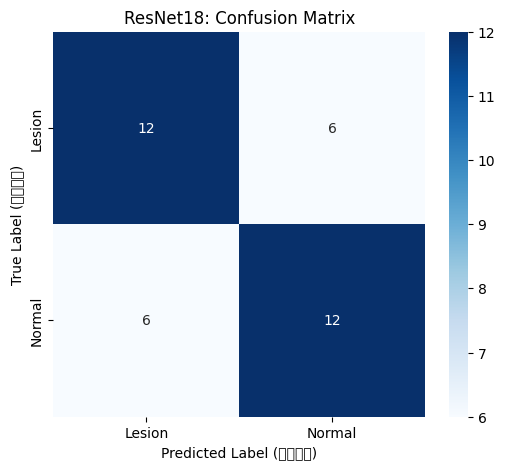

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 確保類別名稱正確
classes = ['Lesion', 'Normal']

# 1. 載入上一個步驟存下的 ResNet18 最佳權重
model.load_state_dict(torch.load('best_resnet18_model.pth'))
model.eval()  # 設定為評估模式

all_preds = []
all_labels = []

print("正在使用未曾見過的「測試集 (Test Set)」進行最終驗證...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. 印出詳細的分類報告
print("===== ResNet18 最終測試集 (Test Set) 評估報告 =====")
print(classification_report(all_labels, all_preds, target_names=classes))

# 3. 繪製混淆矩陣 (Confusion Matrix)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('ResNet18: Confusion Matrix')
plt.ylabel('True Label (實際狀況)')
plt.xlabel('Predicted Label (模型預測)')
plt.show()


解讀範例：

**1. 觀察 Lesion 的 Recall**

在腸胃出血偵測任務中，`Lesion` 的 Recall 很重要，因為 Recall 越高，代表真正有出血的圖片越不容易被模型漏判成正常。如果 ResNet18 的 Lesion Recall 偏低，表示模型可能會漏掉部分出血影像，這在醫療輔助診斷上需要特別注意。

**2. 觀察 Precision 與 False Positive**

如果 Lesion Precision 較低，代表有一些正常圖片被模型誤判成出血。這可能是因為內視鏡影像中有反光、陰影、黏膜顏色較深或皺褶紋理，讓模型誤以為是出血特徵。

**3. 整體 Accuracy 的解讀**

本資料集總共只有 226 張圖片，資料量偏少，因此模型結果可能會受到資料切分方式影響。使用 ResNet18 預訓練模型可以降低小資料集從零訓練造成的不穩定，但仍可能有過擬合問題。建議報告時除了 Accuracy，也要一起說明 Precision、Recall、F1-score 與 Confusion Matrix。

**4. 報告可以這樣說**

本實驗使用 ResNet18 預訓練模型進行腸胃出血影像二分類，分類類別為 Lesion 與 Normal。由於資料集只有 226 張圖片，因此採用 Transfer Learning 的方式，載入 ImageNet 預訓練權重，並將 ResNet18 最後的全連接層改為二分類輸出。訓練過程中加入影像翻轉、旋轉與色彩抖動等資料擴增方法，以降低小資料集造成的過擬合問題。最後使用測試集評估模型，並透過 Accuracy、Precision、Recall、F1-score 與混淆矩陣觀察模型分類效果。
